In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Library primitives only — general loaders, filters, plotters, styling.
# Section-specific configs (group keys, color maps, suptitles) live in the
# cells that use them. Every standard_sweep_figure call gets the AdamW
# baseline + strict-win bar + uniform layout for free.
from lora_playground.plot_utils import (
    DIVERGE_THRESHOLD, OPTIM_COLORS, OPTIM_MARKERS,
    has_runs, load_sweep, max_loss, merge_runs, parse_flag,
    best_run,
    plot_leaderboard_by_rank, standard_sweep_figure,
)
from lora_playground.manifest import (
    groups_by_scope, load_manifests, load_runs_by_scope, warn_untagged,
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [20]:
# Surface any populated log groups missing scope tags. After the manifest
# backfill, this should be silent. If anything appears here it indicates
# a sweep submitted bypassing slurm_scripts/submit.sh.
from lora_playground.manifest import load_manifests, warn_untagged
_mans = load_manifests("../logs", strict=False)
_untagged = warn_untagged(_mans)
if _untagged:
    print(f"WARNING — {len(_untagged)} log group(s) without scope tags:")
    for g in _untagged: print(f"  {g}")
else:
    print(f"OK — all {len(_mans)} populated log groups have scope tags.")

OK — all 50 populated log groups have scope tags.


In [21]:
# Section-specific palettes (general OPTIM_COLORS imported from library).
M_COLORS = {1: plt.cm.plasma(0.15), 4: plt.cm.plasma(0.50), 16: plt.cm.plasma(0.85)}
MODE_COLORS = {"svd_step_oracle": "#ff7f0e", "svd_cumulative_oracle": "#2ca02c"}
MUON_VARIANT_COLORS = {
    "muon":              "#e377c2",
    "muon+m=4":          "#d62728",
    "muon+m=16":         "#8c2d04",
    "muon+ns=0":         "#bababa",
    "product-muon":      "#1f77b4",
    "product-muon+m=4":  "#0d3d66",
    "adam-muon":         "#2ca02c",
    "adam-muon+m=4":     "#0d4f0d",
}

MUON_VARIANT_MARKERS = {
    "muon":              "o",
    "muon+m=4":          "D",
    "muon+m=16":         "P",
    "muon+ns=0":         "x",
    "product-muon":      "o",
    "product-muon+m=4":  "D",
    "adam-muon":         "^",
    "adam-muon+m=4":     "D",
}

## Optimizer comparison by family

Each family panel tests a specific composition class against AdamW. Uninformative low-performers (no-Adam baselines, per-coord K-FAC family, GaLore, unfixed `*-post`) are dropped — they're consistently 0.03+ above AdamW per the synthesis, and clutter the visual without adding signal.

**Caveat on "wins":** small Δ values (< 0.005) are below the project's trajectory-jitter proxy (0.0038) but **trajectory jitter is NOT a calibrated noise floor** — it's a lower bound on seed-to-seed variance. Multi-seed confirmation is deferred. Only `adam-polar-product-lora` at r=64 has Δ=−0.0097 that's clearly above trajectory jitter.

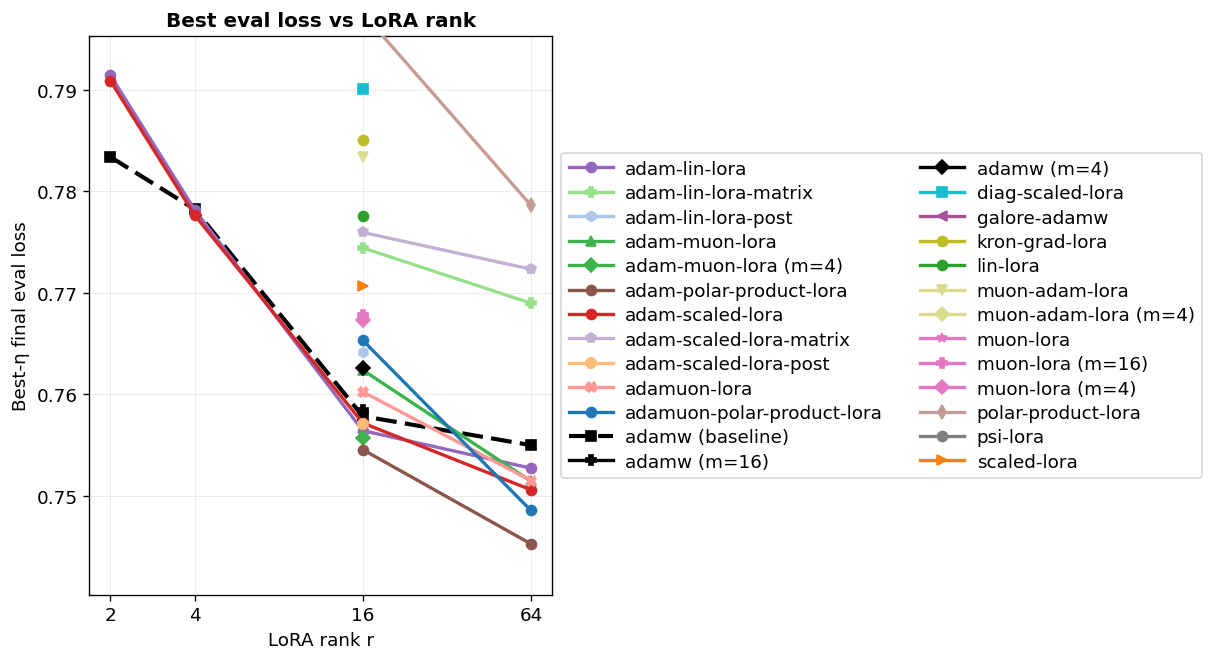

In [22]:
# Optimizer comparison across LoRA ranks: load by scope, plot per-rank best-η + leaderboard.
# Scopes loaded for ext_runs cover every optimizer in OPTIM_COLORS that has data.
# Includes m≠1 (LoRA+) variants as distinct entries — m=1 gets the bare optimizer
# label, m≠1 gets a "(m=N)" suffix so the LoRA+ contribution is visible separately.
_mans = load_manifests("../logs", strict=False)
_groups = []
for scope in ("ext_compare", "muon_family", "polar_family", "all_optimizers", "loraplus_family"):
    for g in groups_by_scope(scope, manifests=_mans, logs_root="../logs"):
        if g not in _groups:
            _groups.append(g)

RENAME_ALIAS = {"psi-lora": "diag-scaled-lora", "kfac-lora": "kron-grad-lora"}
NEW_PSI_GROUPS = {"psi_lora_2k"}

def _alias(c, group):
    c["_lora_r"] = int(c.get("lora_r", 16))
    if group not in NEW_PSI_GROUPS:
        c["optimizer"] = RENAME_ALIAS.get(c["optimizer"], c["optimizer"])
    m = float(c.get("lora_plus_multiplier", 1.0))
    c["_label"] = c["optimizer"] if m == 1.0 else f"{c['optimizer']} (m={int(m)})"

ext_runs = merge_runs(
    _groups,
    key_fn=lambda c: (c["optimizer"], float(c["lr"]), int(c.get("lora_r", 16)),
                      float(c.get("lora_plus_multiplier", 1.0))),
    filter_fn=lambda c: c["optimizer"] in OPTIM_COLORS,
    cfg_postprocess=_alias,
    logs_root="../logs",
)

# Best-η per (label, r) at step 2000 — label includes m so m=1 and m=4 appear separately.
best = {}
for cfg, evs in ext_runs:
    if evs[-1]["step"] < 2000:
        continue
    k = (cfg["_label"], cfg["_lora_r"])
    fl = evs[-1]["eval_loss"]
    if k not in best or fl < best[k][2]:
        best[k] = (cfg, evs, fl)

# Color/marker maps fall back to the base optimizer's entry when the label has "(m=N)".
def _base(label):
    return label.split(" (m=")[0]
_color_map = {lab: OPTIM_COLORS[_base(lab)] for (lab, _) in best if _base(lab) in OPTIM_COLORS}
_color_map["adamw"] = OPTIM_COLORS["adamw"]
_marker_map = {lab: OPTIM_MARKERS.get(_base(lab), "o") for (lab, _) in best}
# m≠1 entries get a distinct marker per m value (m=1 keeps base, m=4=D, m=16=P, m=32=X)
_M_MARKERS = {4: "D", 16: "P", 32: "X"}
import re
for (lab, _) in best:
    m_match = re.search(r"\(m=(\d+)\)", lab)
    if m_match:
        _marker_map[lab] = _M_MARKERS.get(int(m_match.group(1)), "*")

plot_leaderboard_by_rank(best, baseline_optimizer="adamw", color_map=_color_map,
                          marker_map=_marker_map,
                          suptitle="Best eval loss vs LoRA rank")
plt.show()

In [23]:
# all_runs: AdamW + comprehensive baseline data, used downstream as the
# reference overlay for SVD / LoRA+ / muon panels. We do NOT plot all_runs
# as a single 10-curve figure — that's the messy view we removed in the
# family reorg. This cell loads only.
RENAME_ALIAS = {"psi-lora": "diag-scaled-lora", "kfac-lora": "kron-grad-lora"}
NEW_PSI_GROUPS = {"psi_lora_2k"}

def _alias_optimizer(cfg, group):
    if group not in NEW_PSI_GROUPS:
        cfg["optimizer"] = RENAME_ALIAS.get(cfg["optimizer"], cfg["optimizer"])

all_runs = load_runs_by_scope(
    "all_optimizers",
    key_fn=lambda c: (c["optimizer"], float(c["lr"])),
    filter_fn=lambda c: c["optimizer"] in OPTIM_COLORS,
    cfg_postprocess=_alias_optimizer,
)
print(f"all_runs (reference overlay): {len(all_runs)} runs across "
      f"{len({c['optimizer'] for c, _ in all_runs})} optimizers")

all_runs (reference overlay): 77 runs across 10 optimizers


### Pre-Adam (geometry → Adam)

  [filtered diverged] adam-scaled-lora η=1e-02 max=2.269 final=1.665
  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937


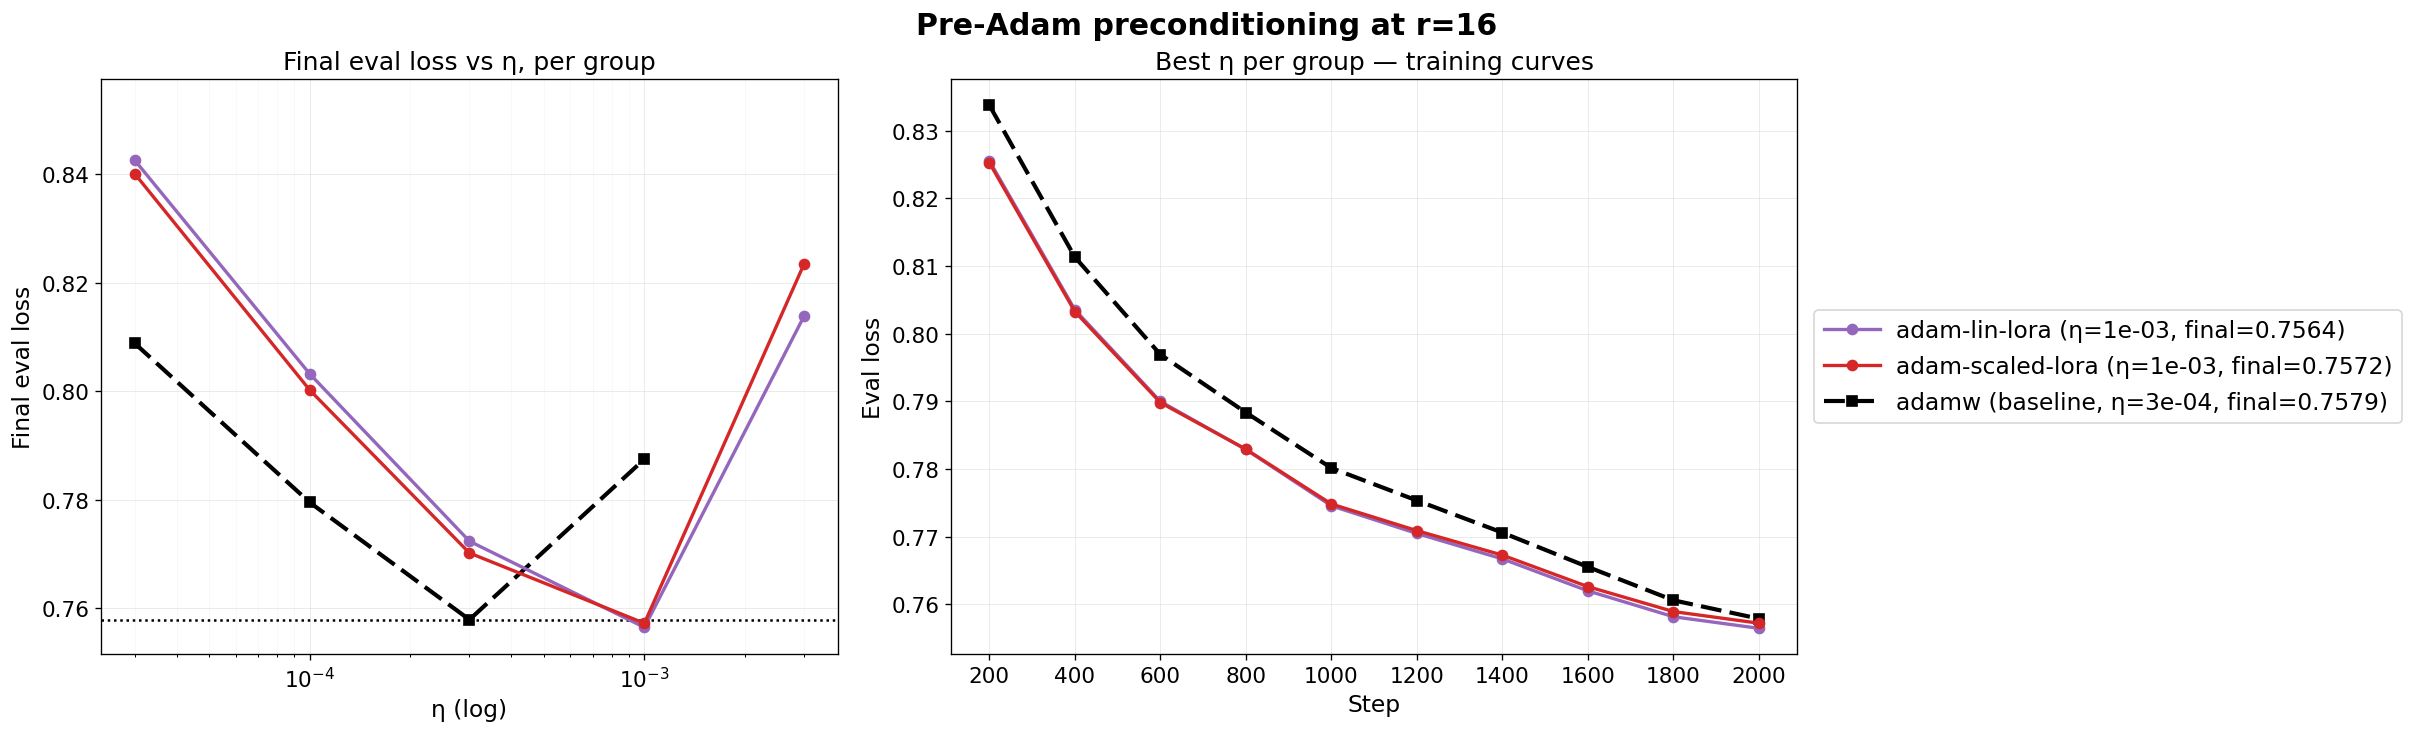

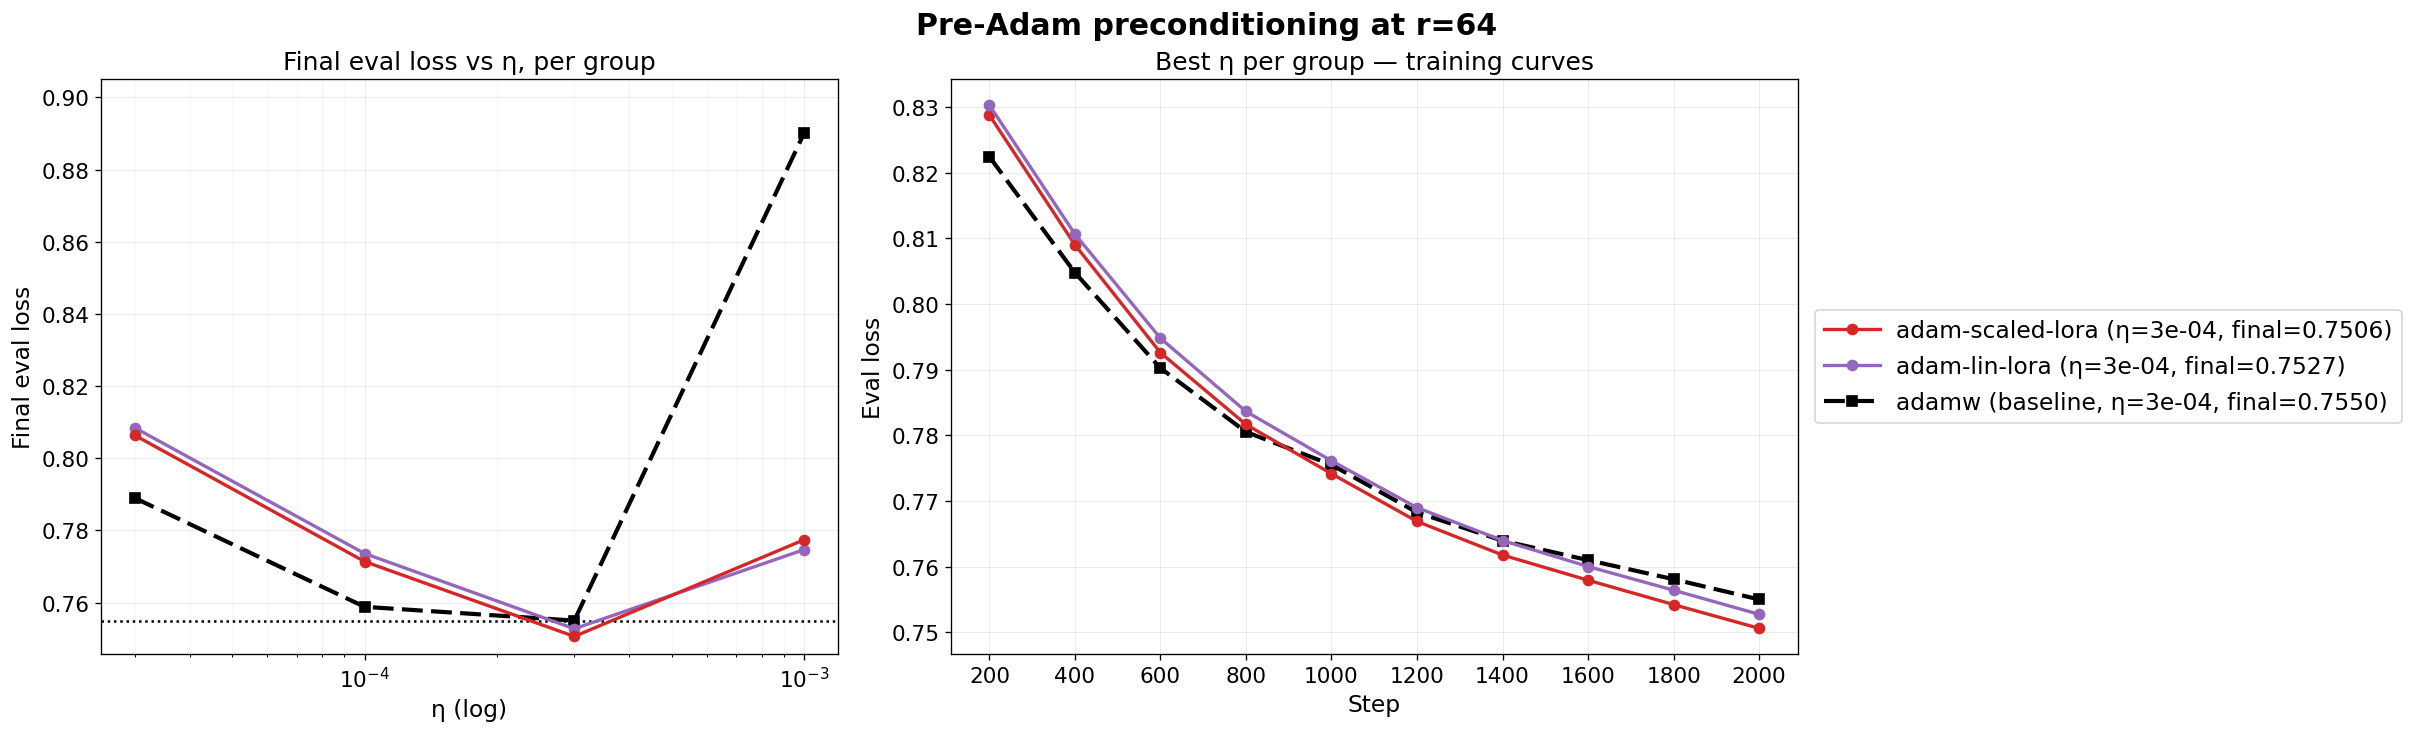

In [24]:
_FAMILY = {'adam-lin-lora', 'adam-scaled-lora', 'adamw'}

# r=16
_runs = [(c, e) for c, e in ext_runs if c["_lora_r"] == 16 and c["optimizer"] in _FAMILY and float(c.get("lora_plus_multiplier", 1.0)) == 1.0]
standard_sweep_figure(
    _runs,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    marker_map=OPTIM_MARKERS,
    reference_runs=_runs,
    suptitle="Pre-Adam preconditioning",
)
plt.show()

# r=64
_runs = [(c, e) for c, e in ext_runs if c["_lora_r"] == 64 and c["optimizer"] in _FAMILY and float(c.get("lora_plus_multiplier", 1.0)) == 1.0]
standard_sweep_figure(
    _runs,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    reference_runs=_runs,
    suptitle="Pre-Adam preconditioning",
)
plt.show()

### Adam → spectral/polar (the headline)

  [filtered diverged] adam-polar-product-lora η=1e-02 max=1.977 final=1.651
  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937


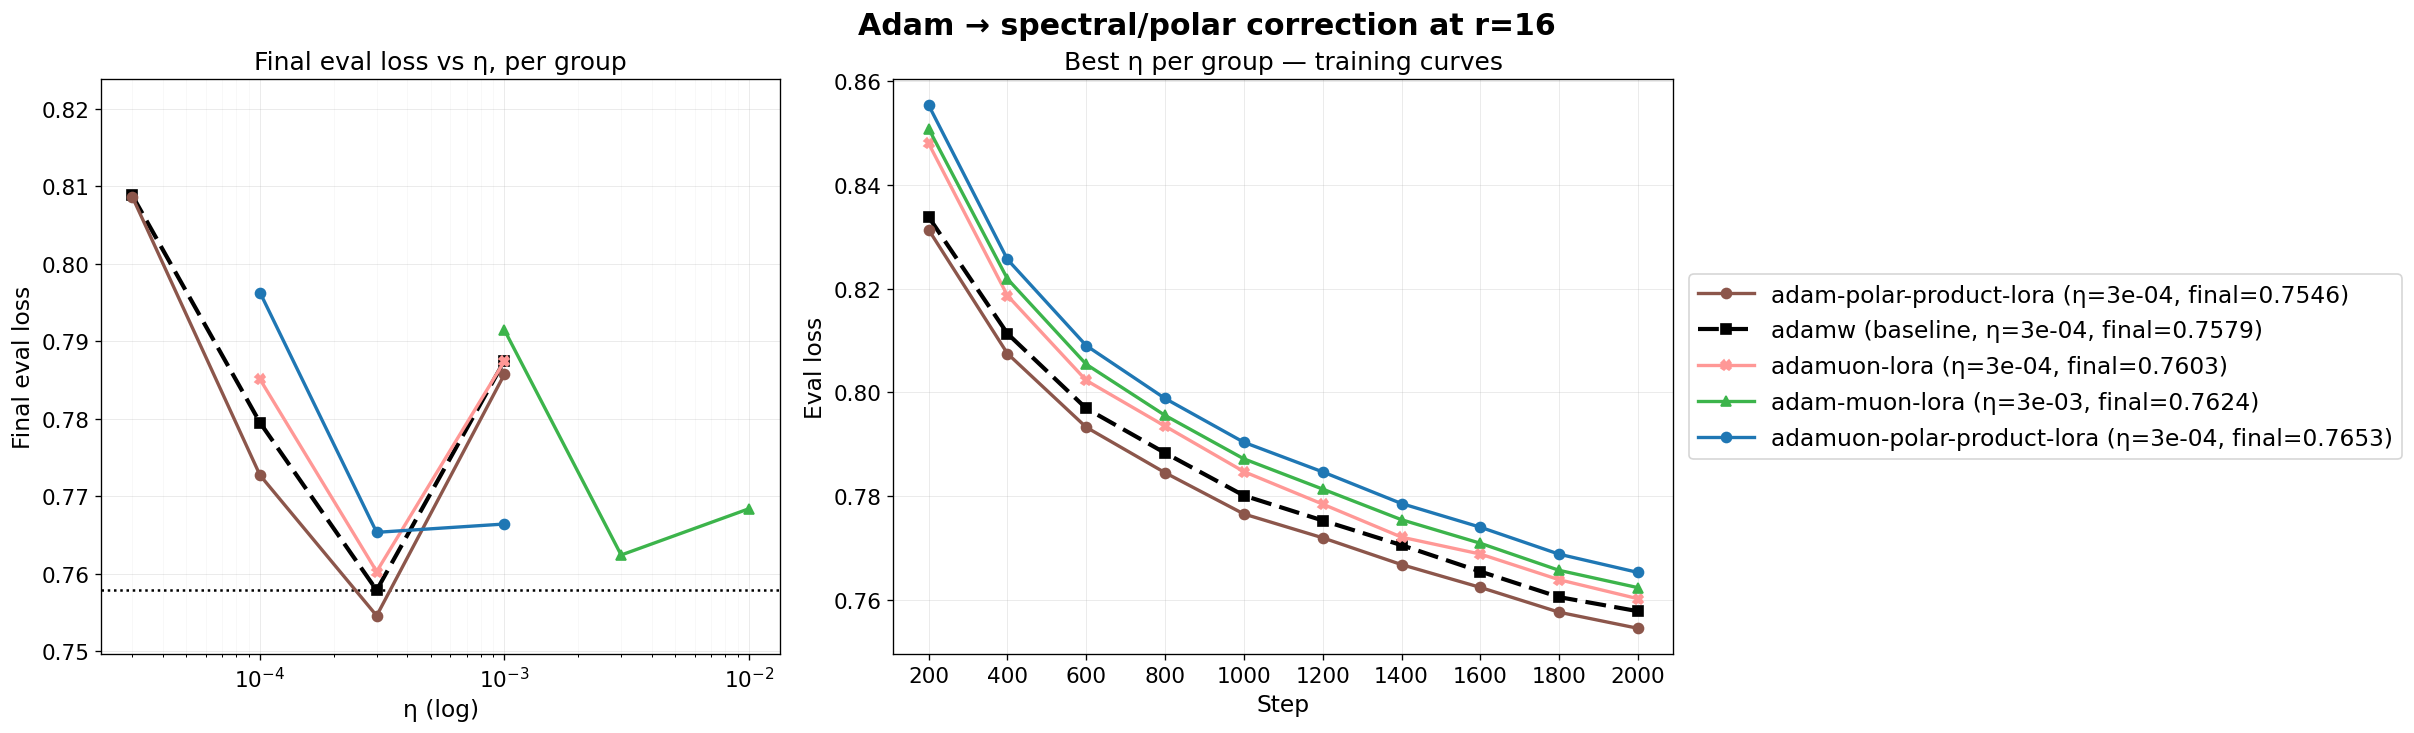

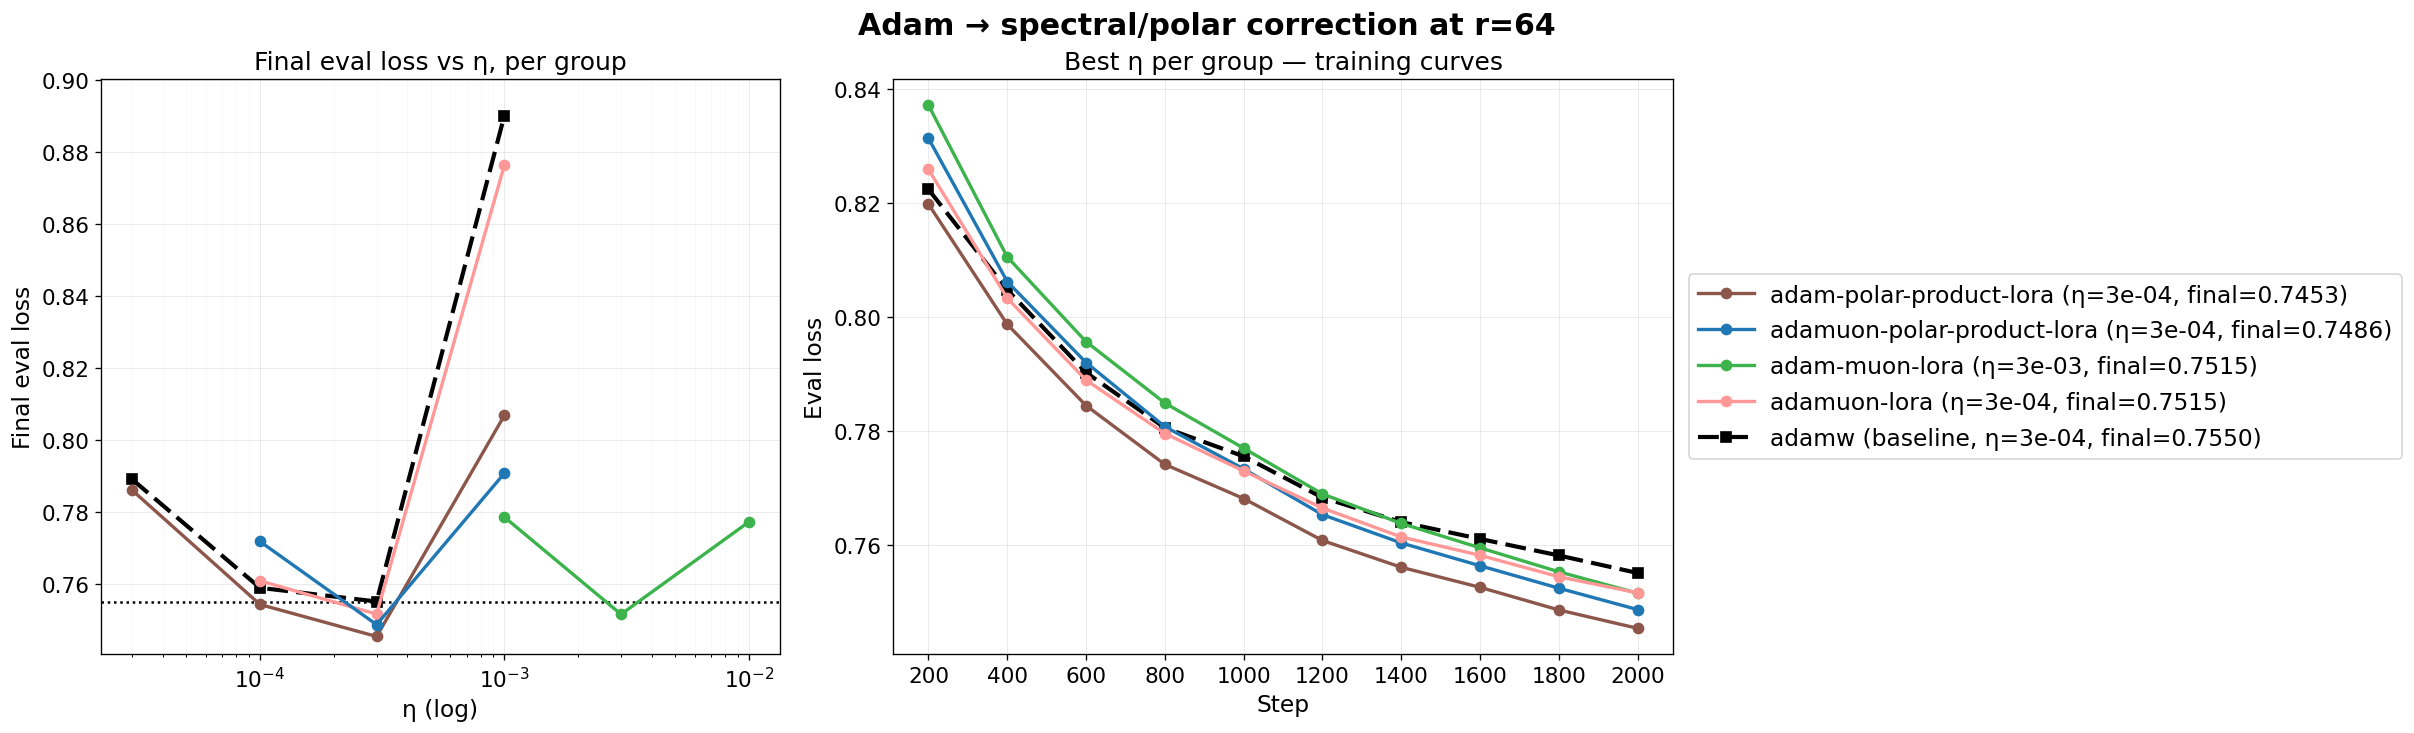

In [25]:
_FAMILY = {'adam-muon-lora', 'adam-polar-product-lora', 'adamuon-lora', 'adamuon-polar-product-lora', 'adamw'}

# r=16
_runs = [(c, e) for c, e in ext_runs if c["_lora_r"] == 16 and c["optimizer"] in _FAMILY and float(c.get("lora_plus_multiplier", 1.0)) == 1.0]
standard_sweep_figure(
    _runs,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    marker_map=OPTIM_MARKERS,
    reference_runs=_runs,
    suptitle="Adam → spectral/polar correction",
)
plt.show()

# r=64
_runs = [(c, e) for c, e in ext_runs if c["_lora_r"] == 64 and c["optimizer"] in _FAMILY and float(c.get("lora_plus_multiplier", 1.0)) == 1.0]
standard_sweep_figure(
    _runs,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    reference_runs=_runs,
    suptitle="Adam → spectral/polar correction",
)
plt.show()

### No-Adam baselines (no per-coord v̂)

  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937


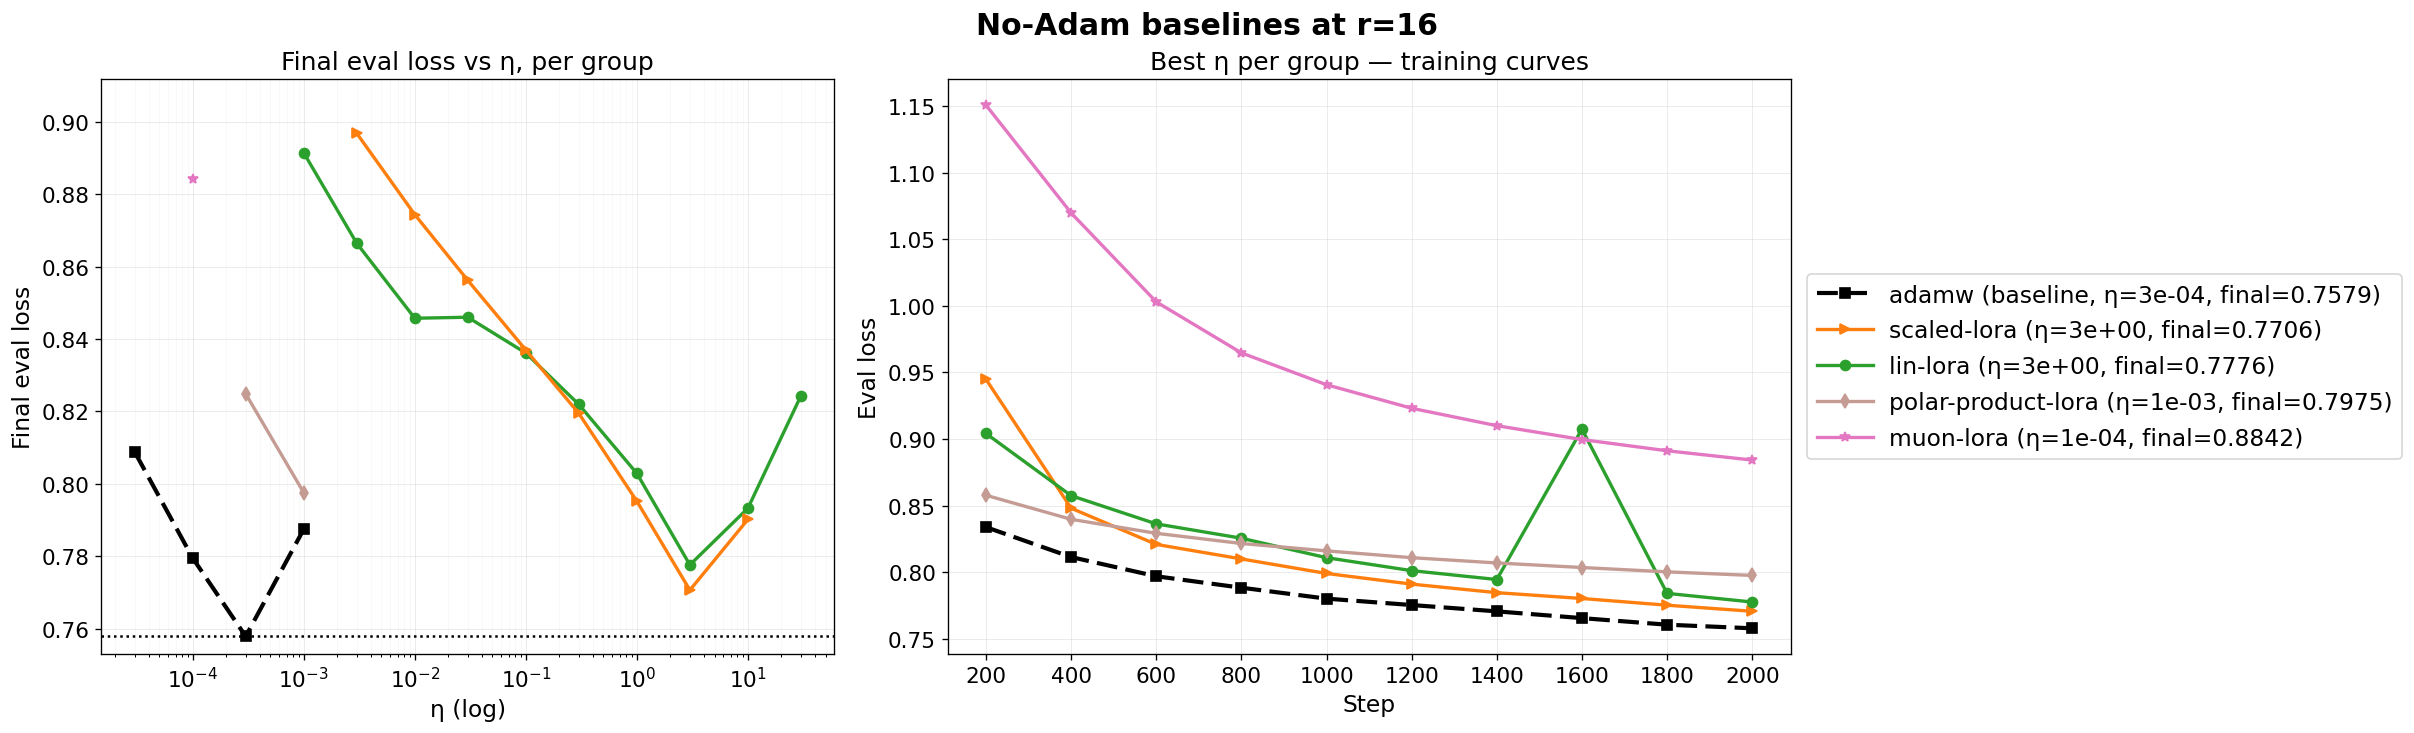

In [26]:
# No-Adam baselines at r=16
_FAMILY = {'adamw', 'muon-lora', 'polar-product-lora', 'lin-lora', 'scaled-lora'}
_runs = [(c, e) for c, e in ext_runs if c["_lora_r"] == 16 and c["optimizer"] in _FAMILY and float(c.get("lora_plus_multiplier", 1.0)) == 1.0]
standard_sweep_figure(
    _runs,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    marker_map=OPTIM_MARKERS,
    reference_runs=_runs,
    suptitle="No-Adam baselines",
)
plt.show()


### Post-Adam corrections (Adam → geometry, falsified family)

  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937


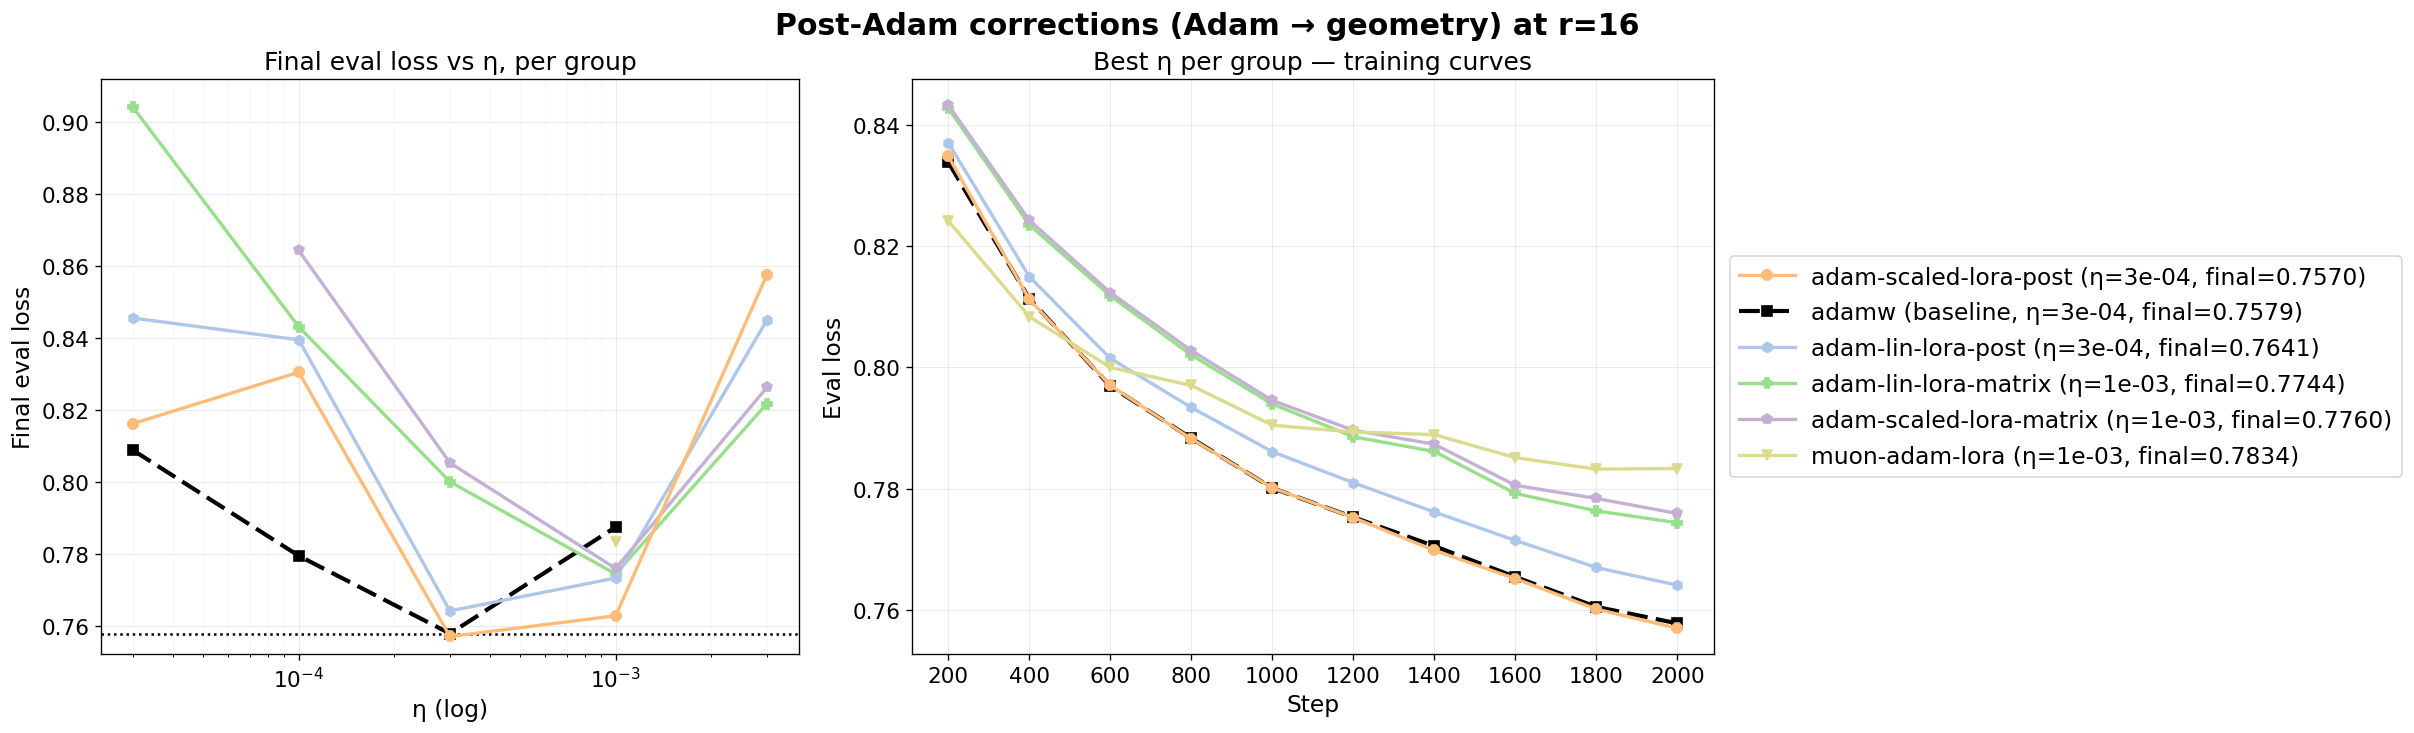

In [27]:
# Post-Adam corrections at r=16
_FAMILY = {'adamw', 'adam-lin-lora-post', 'adam-scaled-lora-post', 'adam-lin-lora-matrix', 'adam-scaled-lora-matrix', 'muon-adam-lora'}
_runs = [(c, e) for c, e in ext_runs if c["_lora_r"] == 16 and c["optimizer"] in _FAMILY and float(c.get("lora_plus_multiplier", 1.0)) == 1.0]
standard_sweep_figure(
    _runs,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    marker_map=OPTIM_MARKERS,
    reference_runs=_runs,
    suptitle="Post-Adam corrections (Adam → geometry)",
)
plt.show()

### Other variants (uninformative reference)

Per-coord K-FAC family, GaLore, and gauge-invariant ProductMuon. Synthesis treats these as uninformative for the headline question — all 0.03+ above AdamW. Plotted for completeness so no optimizer is silently skipped.

  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937
  [filtered diverged] diag-scaled-lora η=1e+00 max=9.292 final=6.136
  [filtered diverged] diag-scaled-lora η=3e+00 max=12.436 final=8.034
  [filtered diverged] galore-adamw η=1e-02     max=1.653 final=1.636
  [filtered diverged] kron-grad-lora η=3e-02   max=9.879 final=4.922
  [filtered partial from left panel] 1 run(s) below min_step=2000:
    psi-lora η=1e-02               step=400 final-so-far=0.9433


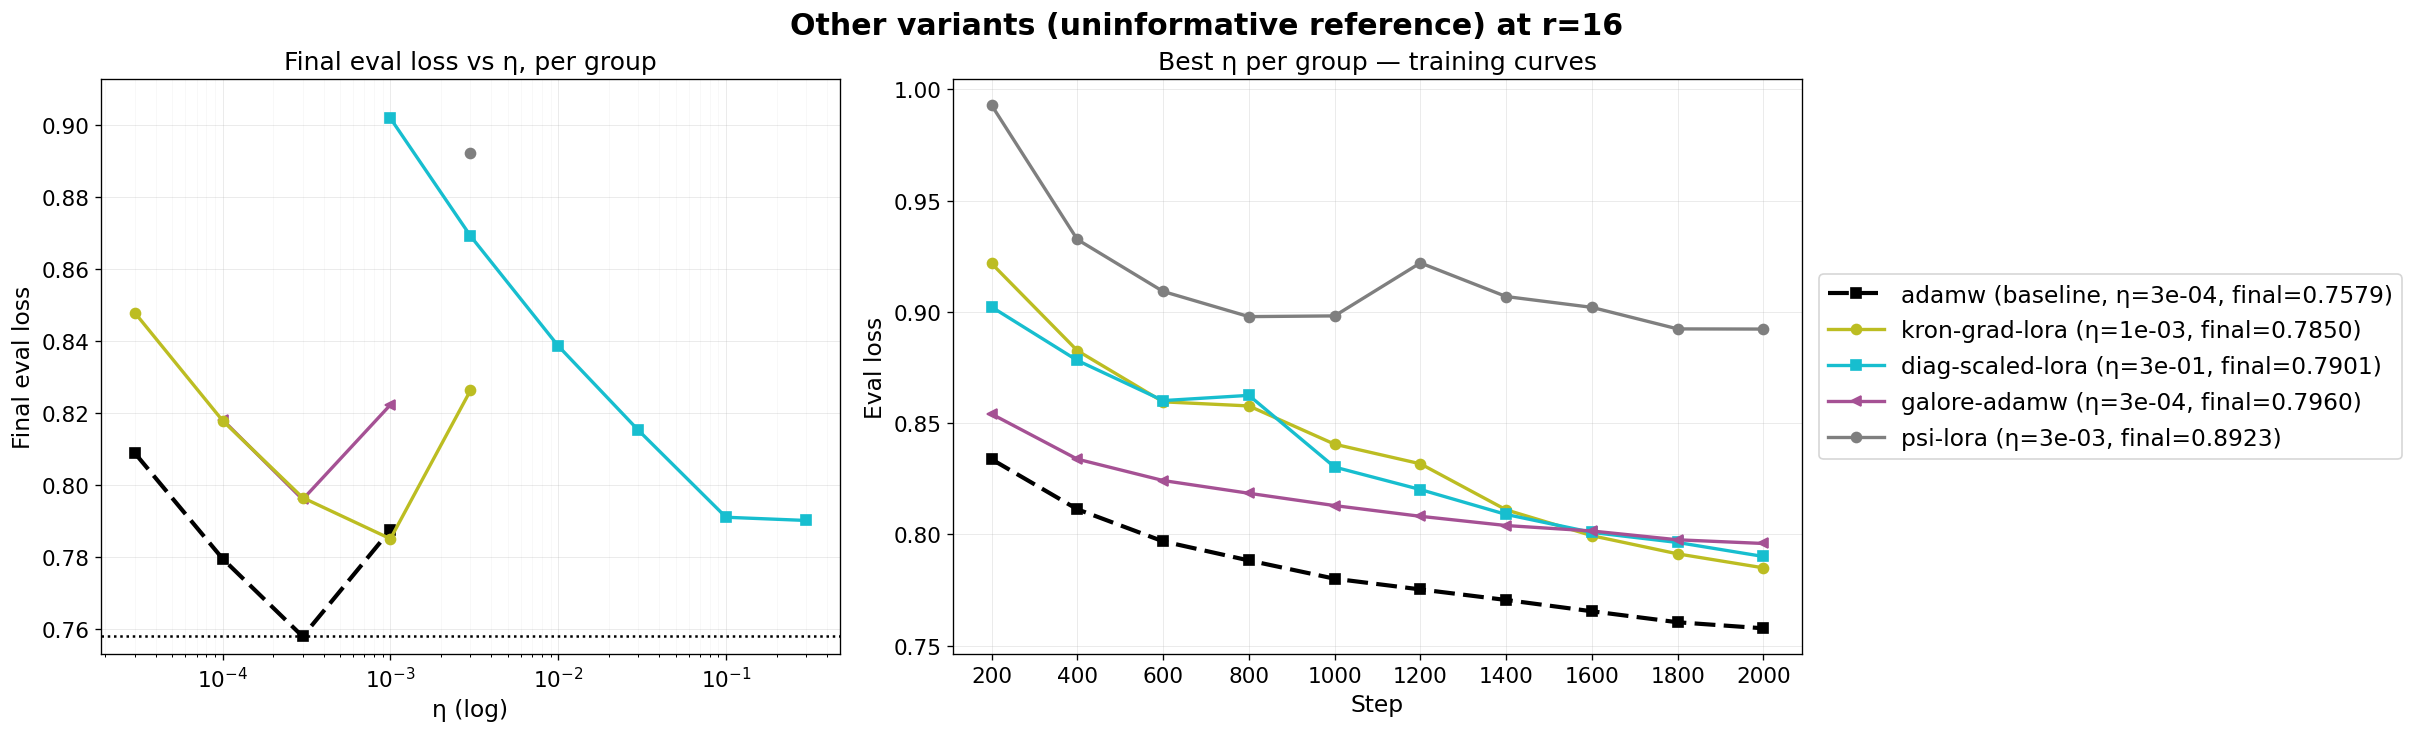

In [28]:
# Other variants at r=16 — uninformative low-performers
_FAMILY = {'adamw', 'product-muon-lora', 'adam-product-muon-lora', 'diag-scaled-lora', 'kron-grad-lora', 'psi-lora', 'galore-adamw'}
_runs = [(c, e) for c, e in ext_runs if c["_lora_r"] == 16 and c["optimizer"] in _FAMILY and float(c.get("lora_plus_multiplier", 1.0)) == 1.0]
standard_sweep_figure(
    _runs,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    marker_map=OPTIM_MARKERS,
    reference_runs=_runs,
    suptitle="Other variants (uninformative reference)",
)
plt.show()

## Muon-LoRA variants — beat AdamW campaign

Hypothesis-driven sweep:
- **Tier 1 (`muon_loraplus_2k`)**: H1 — LoRA+ asymmetry on B's lr (m ∈ {4, 16}). Baseline m=1 reused from earlier groups.
- **Tier 2 (`muon_nsoff_2k`)**: H3 sanity — `--muon_ns_steps 0` ⇒ momentum SGD (NS disabled). If matches Muon-LoRA, the orthogonalization is irrelevant.
- **Tier 3 (`product_muon_2k`)**: H2 — `ProductMuonLoRA`, NS on the merged-direction proxy `D = (1/scale)·m_B·(AAᵀ+δI)⁻¹·A` then Sylvester-recovered. Theory: `docs/theory/main.tex` line 622+.
- **Tier 4 (`adam_muon_2k`)**: H4 — `AdamMuonLoRA`, NS on Adam's m̂/(√v̂+ε) direction.

Reference frontiers (from earlier sweeps): AdamW @ 0.7579, adam-lin-lora @ 0.7564. Goal: **strictly beat** both.

In [29]:
def _stamp_muon_meta(cfg, group):
    """Inject muon_ns_steps from --muon_ns_steps (default 5)."""
    v = parse_flag(cfg.get("command", ""), "--muon_ns_steps")
    cfg["muon_ns_steps"] = int(v) if v is not None else 5

muon_runs = load_runs_by_scope(
    "muon_family",
    key_fn=lambda c: (c["optimizer"], float(c["lr"]),
                      float(c.get("lora_plus_multiplier", 1.0)),
                      c["muon_ns_steps"], int(c.get("lora_r", 16))),
    filter_fn=lambda c: c["optimizer"] in {"muon-lora", "product-muon-lora", "adam-muon-lora"} and c["muon_ns_steps"] != 0,
    cfg_postprocess=_stamp_muon_meta,
)

print(f"Loaded {len(muon_runs)} Muon-family runs")
for cfg, evs in sorted(muon_runs, key=lambda x: (x[0]["optimizer"], x[0]["muon_ns_steps"],
                                                  x[0]["lora_plus_multiplier"], x[0]["lr"])):
    flag = " DIVERGED" if max_loss(evs) >= DIVERGE_THRESHOLD else ""
    print(f"  {cfg['optimizer']:<18s}  η={cfg['lr']:.0e}  "
          f"m={float(cfg['lora_plus_multiplier']):>4.1f}  "
          f"ns={cfg['muon_ns_steps']}  final={evs[-1]['eval_loss']:.4f}{flag}")

Loaded 22 Muon-family runs
  adam-muon-lora      η=1e-03  m= 1.0  ns=5  final=0.7914
  adam-muon-lora      η=1e-03  m= 1.0  ns=5  final=0.7785
  adam-muon-lora      η=3e-03  m= 1.0  ns=5  final=0.7624
  adam-muon-lora      η=3e-03  m= 1.0  ns=5  final=0.7515
  adam-muon-lora      η=1e-02  m= 1.0  ns=5  final=0.7684
  adam-muon-lora      η=1e-02  m= 1.0  ns=5  final=0.7771
  adam-muon-lora      η=1e-03  m= 4.0  ns=5  final=0.7670
  adam-muon-lora      η=3e-03  m= 4.0  ns=5  final=0.7557
  muon-lora           η=3e-05  m= 1.0  ns=5  final=1.0015
  muon-lora           η=1e-04  m= 1.0  ns=5  final=0.8842
  muon-lora           η=3e-04  m= 1.0  ns=5  final=0.8291
  muon-lora           η=1e-03  m= 1.0  ns=5  final=0.7873
  muon-lora           η=1e-04  m= 4.0  ns=5  final=0.8377
  muon-lora           η=3e-04  m= 4.0  ns=5  final=0.7978
  muon-lora           η=1e-03  m= 4.0  ns=5  final=0.7674
  muon-lora           η=3e-03  m= 4.0  ns=5  final=0.7759
  muon-lora           η=1e-02  m= 4.0  ns=5  

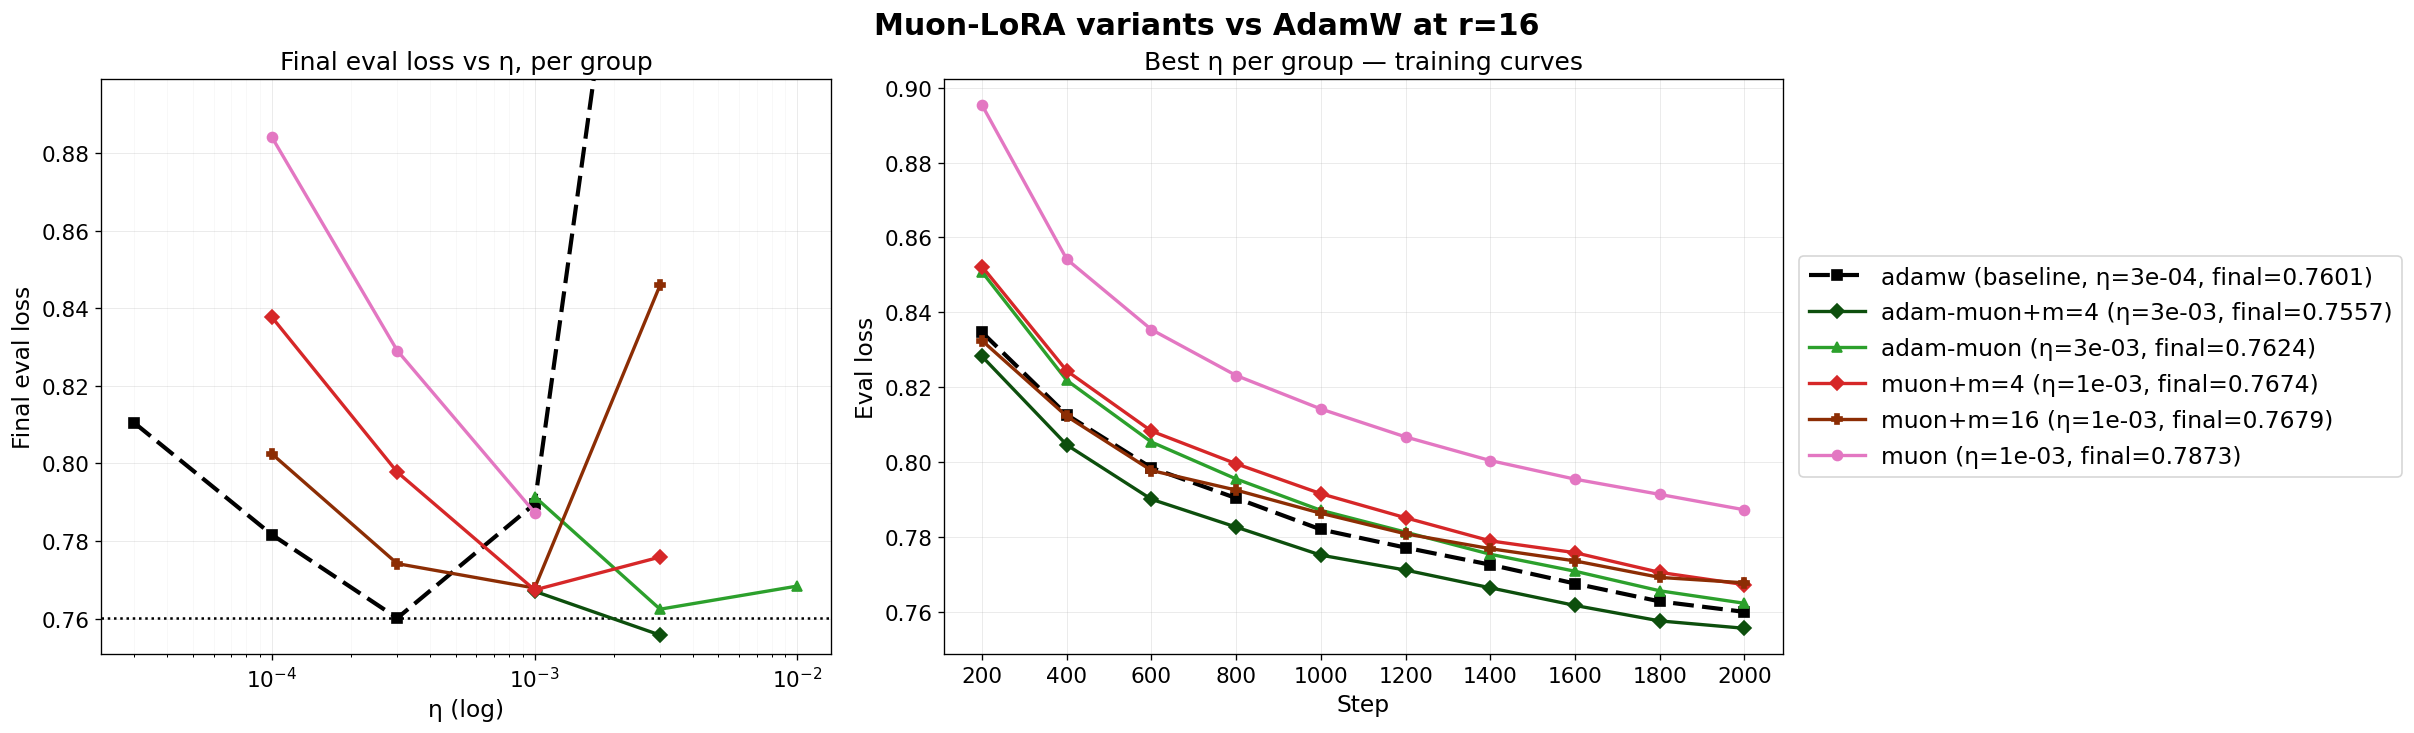

In [30]:
def _muon_variant(cfg):
    opt = cfg["optimizer"]
    m = float(cfg.get("lora_plus_multiplier", 1.0))
    ns = cfg.get("muon_ns_steps", 5)
    base = {"muon-lora": "muon", "product-muon-lora": "product-muon",
            "adam-muon-lora": "adam-muon"}[opt]
    parts = [base]
    if m != 1.0: parts.append(f"m={int(m)}")
    if ns == 0:  parts.append("ns=0")
    return "+".join(parts)

muon_runs_r16 = [(c, e) for c, e in muon_runs if int(c.get("lora_r", 16)) == 16]
standard_sweep_figure(
    muon_runs_r16,
    group_key_fn=_muon_variant,
    color_map=MUON_VARIANT_COLORS,
    same_value_axes=(),  # explicit m axis in group label
    marker_map=MUON_VARIANT_MARKERS,
    reference_runs=all_runs,
    suptitle="Muon-LoRA variants vs AdamW",
)
plt.show()

## SVD oracle — step vs cumulative, η sweep, r=16, 1 epoch

`svd_step_oracle`: each AdamW step projected to rank r via randomized SVD (niter=4).  
`svd_cumulative_oracle`: cumulative displacement from init projected to rank r.  
Both use full dense weights (not LoRA adapters). Reference: best AdamW LoRA at η=3e-4.

In [31]:
svd_runs = load_sweep("svd_sweep_2k_1ep")
print(f"Loaded {len(svd_runs)} SVD oracle runs")
for cfg, evs in sorted(svd_runs, key=lambda x: (x[0]["training_mode"], x[0]["lr"])):
    flag = " DIVERGED" if max_loss(evs) >= DIVERGE_THRESHOLD else ""
    print(f"  {cfg['training_mode']:<25s}  η={cfg['lr']:.0e}  "
          f"final={evs[-1]['eval_loss']:.4f}{flag}")

Loaded 8 SVD oracle runs
  svd_cumulative_oracle      η=3e-05  final=0.8065
  svd_cumulative_oracle      η=1e-04  final=0.7869
  svd_cumulative_oracle      η=3e-04  final=0.9734
  svd_cumulative_oracle      η=1e-03  final=3.8249 DIVERGED
  svd_step_oracle            η=3e-05  final=0.8773
  svd_step_oracle            η=1e-04  final=0.8053
  svd_step_oracle            η=3e-04  final=0.8139
  svd_step_oracle            η=1e-03  final=2.6889 DIVERGED


  [filtered diverged] svd_cumulative_oracle η=1e-03 max=4.921 final=3.825
  [filtered diverged] svd_step_oracle η=1e-03  max=4.947 final=2.689


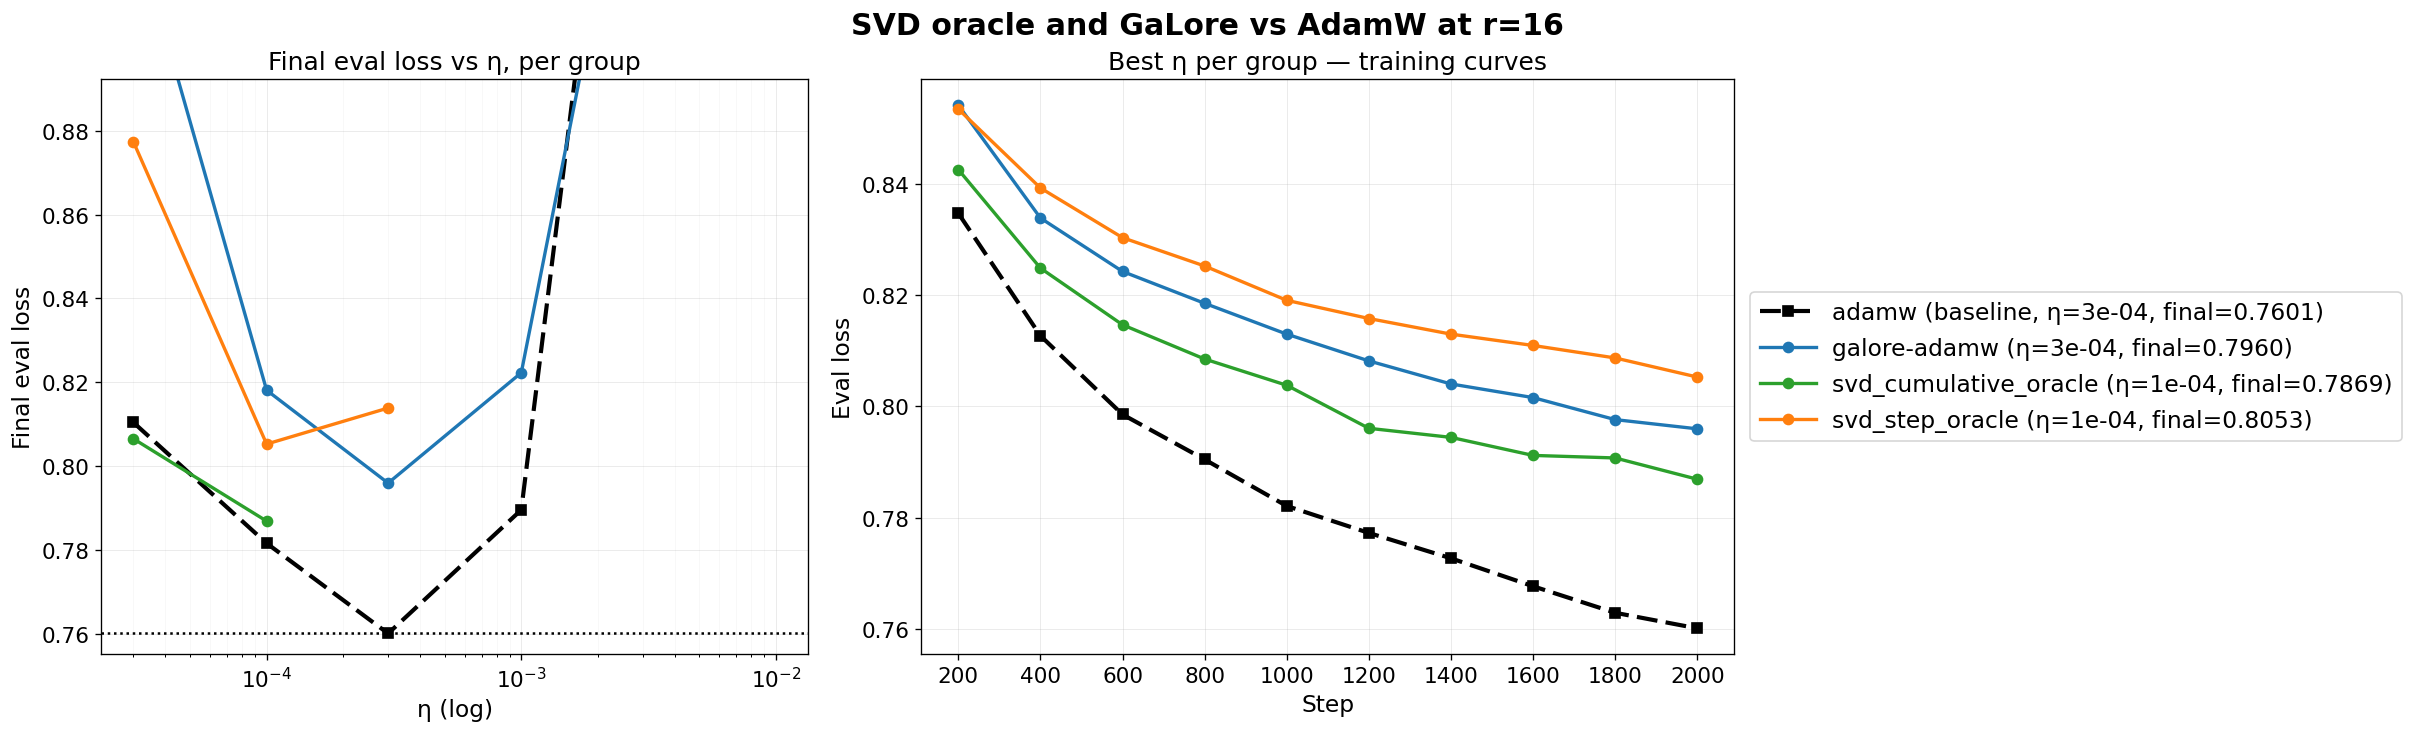

In [32]:
standard_sweep_figure(
    svd_runs,
    group_key_fn=lambda c: c["training_mode"],
    color_map=MODE_COLORS,
    reference_runs=all_runs,
    extra_baselines=(("galore-adamw", "#1f77b4"),),
    suptitle="SVD oracle and GaLore vs AdamW",
)
plt.show()

## LoRA+ (η, m) co-sweep — AdamW, r=16, 1 epoch

In [33]:
# AdamW LoRA+ runs by scope. Drop m=1 (== plain adamw, redundant)
# and m≥32 (training blows up at this scale).
def _lp_filter(c):
    if c.get('optimizer') != 'adamw':
        return False
    m = float(c.get('lora_plus_multiplier', 1.0))
    return 1.0 < m < 32.0

lp_runs = load_runs_by_scope(
    'loraplus_family',
    key_fn=lambda c: (float(c.get('lora_plus_multiplier', 1.0)), float(c['lr'])),
    filter_fn=_lp_filter,
)
print(f'Loaded {len(lp_runs)} AdamW LoRA+ runs (merged, m ∈ (1, 32))')
for cfg, evs in sorted(lp_runs, key=lambda x: (x[0].get('lora_plus_multiplier', 1), x[0]['lr'])):
    print(f"  m={cfg.get('lora_plus_multiplier', 1):.0f}  "
          f"η={cfg['lr']:.0e}  final={evs[-1]['eval_loss']:.4f}")

Loaded 8 AdamW LoRA+ runs (merged, m ∈ (1, 32))
  m=4  η=1e-05  final=0.8163
  m=4  η=3e-05  final=0.7905
  m=4  η=1e-04  final=0.7626
  m=4  η=3e-04  final=0.7644
  m=16  η=1e-05  final=0.7940
  m=16  η=3e-05  final=0.7684
  m=16  η=1e-04  final=0.7585
  m=16  η=3e-04  final=0.8128


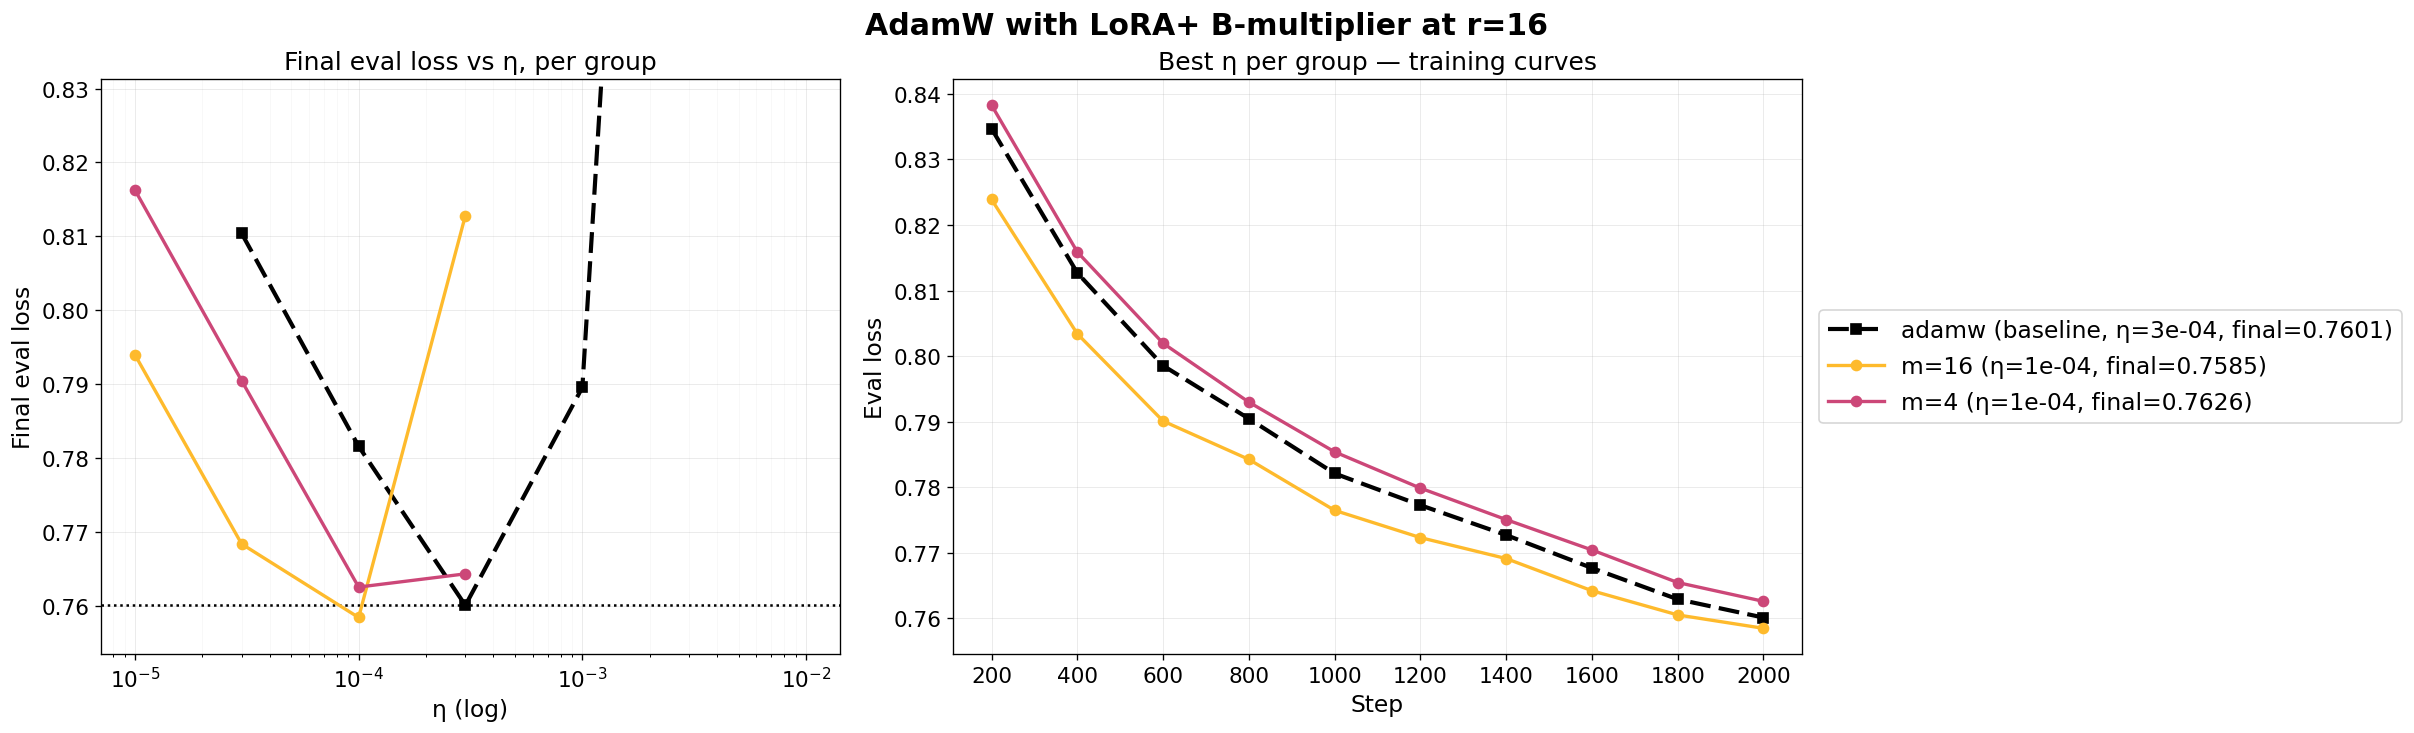

In [34]:
def _lp_group(cfg):
    return f"m={int(round(cfg.get('lora_plus_multiplier', 1.0)))}"

LP_COLOR_MAP = {f"m={m}": c for m, c in M_COLORS.items()}

standard_sweep_figure(
    lp_runs,
    group_key_fn=_lp_group,
    color_map=LP_COLOR_MAP,
    same_value_axes=(),  # explicit m axis in group label
    reference_runs=all_runs,
    suptitle="AdamW with LoRA+ B-multiplier",
)
plt.show()